# Pipeline Test
Run each stage of the pipeline end-to-end: ingest → chunk → extract frames → caption.

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"Repo root: {repo_root}")

Repo root: /workspaces/DiveVisionApp


## 1. Ingestion
Scan raw videos and register them in `video_registry.json`.

In [2]:
from src.ingestion import register_video, load_registry
from src.constants import RAW_VIDEO_DIR, VIDEO_REGISTRY_JSON

video_extensions = {".mp4", ".MP4", ".mov", ".MOV"}
raw_videos = [p for p in RAW_VIDEO_DIR.iterdir() if p.suffix in video_extensions]
print(f"Found {len(raw_videos)} video(s) in {RAW_VIDEO_DIR}:")
for v in raw_videos:
    print(f"  {v.name}")

Found 3 video(s) in /workspaces/DiveVisionApp/data/raw:
  GX014538.MP4
  B666D060-459D-41A4-A148-3560CD31A078.mp4
  GX014580.MP4


In [3]:
for video_path in raw_videos:
    print(f"Registering: {video_path.name}")
    register_video(video_path)
    print()

video_registry = load_registry()
print(f"Registry has {len(video_registry)} video(s). Saved to: {VIDEO_REGISTRY_JSON}")

Registering: GX014538.MP4
  Already registered: GX014538.MP4 (video_id=5cfb519d-46ad-4bfb-ad32-8317be28a0b1)

Registering: B666D060-459D-41A4-A148-3560CD31A078.mp4
  Already registered: B666D060-459D-41A4-A148-3560CD31A078.mp4 (video_id=a5965e4c-94e2-4205-b17a-3e65980ecb22)

Registering: GX014580.MP4
  Already registered: GX014580.MP4 (video_id=cd584e9e-6777-4944-bdc5-429f2b7dbcf2)

Registry has 3 video(s). Saved to: /workspaces/DiveVisionApp/data/processed/video_registry.json


In [4]:
# Inspect a single video record
video_id, record = next(iter(video_registry.items()))
import pprint
pprint.pprint(record)

{'created_on': '2025-08-27T15:42:48',
 'duration_s': 34.6,
 'filename': 'GX014538.MP4',
 'filepath': '/workspaces/DiveVisionApp/data/raw/GX014538.MP4',
 'fps': 29.97,
 'frame_count': 1037,
 'gps_end_ts': '2025-08-27T07:43:19.664000+00:00',
 'gps_lat_max': -8.514584,
 'gps_lat_min': -8.514584,
 'gps_lon_max': 119.57411,
 'gps_lon_min': 119.57411,
 'gps_start_ts': '2025-08-27T07:42:44.299000+00:00',
 'height': 1920,
 'iso_max': 368,
 'iso_min': 149,
 'modified_on': '2025-08-27T15:42:48',
 'video_id': '5cfb519d-46ad-4bfb-ad32-8317be28a0b1',
 'width': 1080}


## 2. Chunking
Split each video into 20-second chunks and save to `chunk_registry.json`.

In [5]:
from src.chunk_video import build_chunk_registry, save_chunk_registry, CHUNK_REGISTRY_JSON, CHUNK_DURATION_S

chunk_registry = build_chunk_registry()
save_chunk_registry(chunk_registry)

total_videos = len({c["video_id"] for c in chunk_registry.values()})
print(f"Chunked {total_videos} video(s) into {len(chunk_registry)} chunks ({CHUNK_DURATION_S}s each)")
print(f"Saved to: {CHUNK_REGISTRY_JSON}")

Chunked 3 video(s) into 7 chunks (20.0s each)
Saved to: /workspaces/DiveVisionApp/data/processed/chunk_registry.json


In [6]:
# Inspect chunks per video
for chunk_id, chunk in chunk_registry.items():
    vid = video_registry[chunk["video_id"]]
    print(f"  {vid['filename']}  chunk {chunk['chunk_index']:03d}: {chunk['start_s']}s – {chunk['end_s']}s  ({chunk['duration_s']}s)")

  GX014538.MP4  chunk 000: 0.0s – 20.0s  (20.0s)
  GX014538.MP4  chunk 001: 20.0s – 34.6s  (14.6s)
  B666D060-459D-41A4-A148-3560CD31A078.mp4  chunk 000: 0.0s – 20.0s  (20.0s)
  B666D060-459D-41A4-A148-3560CD31A078.mp4  chunk 001: 20.0s – 40.0s  (20.0s)
  B666D060-459D-41A4-A148-3560CD31A078.mp4  chunk 002: 40.0s – 59.63s  (19.63s)
  GX014580.MP4  chunk 000: 0.0s – 20.0s  (20.0s)
  GX014580.MP4  chunk 001: 20.0s – 24.46s  (4.46s)


## 3. Frame Extraction
Sample a frame every 3.33 seconds from each chunk and save as JPEGs.

In [7]:
from src.extract_frames import extract_all_frames, SAMPLE_INTERVAL_S
from src.constants import FRAMES_DIR

frame_results = extract_all_frames()

total_frames = sum(len(paths) for paths in frame_results.values())
print(f"Extracted {total_frames} frames across {len(frame_results)} chunks (every {SAMPLE_INTERVAL_S}s)")
print(f"Saved under: {FRAMES_DIR}")

Extracted 41 frames across 7 chunks (every 3.33s)
Saved under: /workspaces/DiveVisionApp/data/processed/frames


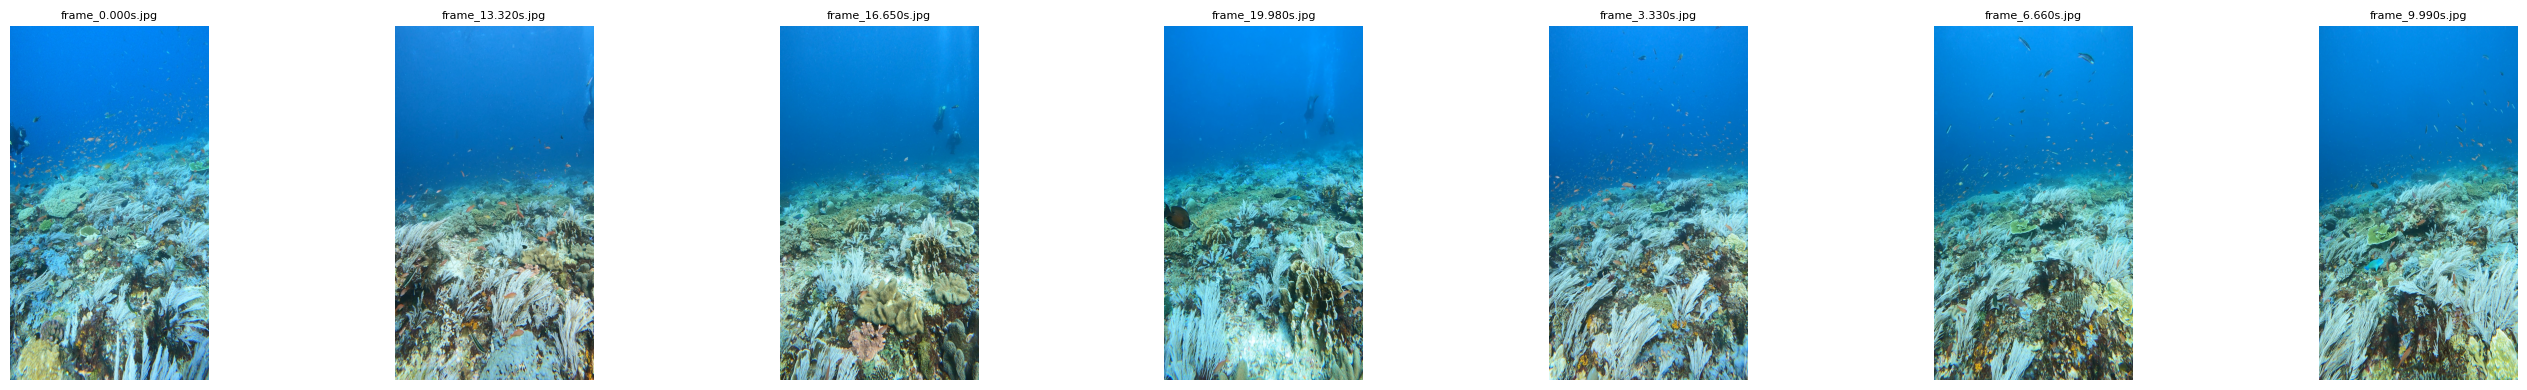

In [8]:
# Preview extracted frames for one chunk
import matplotlib.pyplot as plt
from PIL import Image

sample_chunk_id = next(iter(frame_results))
sample_paths = sorted(frame_results[sample_chunk_id])

fig, axes = plt.subplots(1, len(sample_paths), figsize=(4 * len(sample_paths), 4))
if len(sample_paths) == 1:
    axes = [axes]
for ax, p in zip(axes, sample_paths):
    ax.imshow(Image.open(p))
    ax.set_title(p.name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Captioning
Run BLIP on each frame and save captions to `caption_registry.json`.

In [9]:
from src.caption_frames import load_model, caption_image, CAPTION_REGISTRY_JSON

processor, model = load_model()
print("Model loaded.")

/workspaces/DiveVisionApp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 616/616 [00:14<00:00, 41.59it/s] 


Model loaded.


frame_0.000s.jpg: there is a man swimming in the ocean with a lot of fish


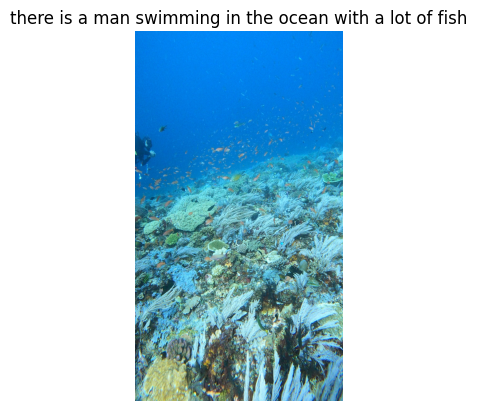

In [10]:
# Test captioning on a single frame before running the full pipeline
test_frame = sample_paths[0]
caption = caption_image(test_frame, processor, model)
print(f"{test_frame.name}: {caption}")

img = Image.open(test_frame)
plt.imshow(img)
plt.title(caption, wrap=True)
plt.axis("off")
plt.show()

In [11]:
# Run captioning across all chunks (writes caption_registry.json)
from src.caption_frames import caption_all_chunks

caption_registry = caption_all_chunks()
print(f"\nCaption registry saved to: {CAPTION_REGISTRY_JSON}")

Loading weights: 100%|██████████| 616/616 [00:00<00:00, 3936.62it/s]


  frame_0.000s.jpg: there is a man swimming in the ocean with a lot of fish
  frame_13.320s.jpg: there is a person swimming in the ocean with a scuba board
  frame_16.650s.jpg: there are two divers in the water near a coral reef
  frame_19.980s.jpg: there are two divers in the water with a variety of corals
  frame_3.330s.jpg: there is a large amount of fish swimming in the ocean
  frame_6.660s.jpg: there are many fish swimming in the ocean near a coral reef
  frame_9.990s.jpg: there is a fish that is swimming in the ocean
Captioned chunk 861df046-84cd-42d1-8419-2ecfe6eba619 (7 frames)
  frame_20.000s.jpg: there are two divers in the water with a variety of corals
  frame_23.330s.jpg: there are two divers in the water near a coral reef
  frame_26.660s.jpg: there are many different types of corals on the ocean floor
  frame_29.990s.jpg: there is a large group of fish swimming over a coral reef
  frame_33.320s.jpg: there is a large group of fish swimming on a coral reef
Captioned chunk 1

In [ ]:
# # Inspect the caption registry
# import json
# from src.constants import CAPTION_REGISTRY_JSON, VIDEO_REGISTRY_JSON, CHUNK_REGISTRY_JSON

# import json                                                                   
                                                                            
# # with open(CAPTION_REGISTRY_JSON, 'r') as f:                                             
# #     caption_registry = json.load(f)
# # with open(VIDEO_REGISTRY_JSON, 'r') as f:                                             
# #     video_registry = json.load(f)
# # with open(CHUNK_REGISTRY_JSON, 'r') as f:                                             
# #     chunk_registry = json.load(f)

# caption_data = json.loads(CAPTION_REGISTRY_JSON.read_text())
# video_registry = json.loads(VIDEO_REGISTRY_JSON.read_text())
# chunk_registry = json.loads(CHUNK_REGISTRY_JSON.read_text())

# for chunk_id, entry in caption_data.items():
#     vid = video_registry[entry["video_id"]]
#     print(f"\n{vid['filename']} — chunk {entry['chunk_index']:03d}")
#     for frame_name, cap in entry["captions"].items():
#         print(f"  {frame_name}: {cap}")
    
# def score_check(query: str):
#     """Just print scores without extracting, to help calibrate threshold."""
#     query_embedding = embedder.encode(query).tolist()
#     results = collection.query(
#         query_embeddings=[query_embedding],
#         n_results=20,
#         include=["documents", "distances"]
#     )
#     for doc, dist in zip(results["documents"][0], results["distances"][0]):
#         print(f"{1-dist:.2f} | {doc[:80]}") 

# score_check("turtle")


GX014538.MP4 — chunk 000
  frame_0.000s.jpg: there is a man swimming in the ocean with a lot of fish
  frame_13.320s.jpg: there is a person swimming in the ocean with a scuba board
  frame_16.650s.jpg: there are two divers in the water near a coral reef
  frame_19.980s.jpg: there are two divers in the water with a variety of corals
  frame_3.330s.jpg: there is a large amount of fish swimming in the ocean
  frame_6.660s.jpg: there are many fish swimming in the ocean near a coral reef
  frame_9.990s.jpg: there is a fish that is swimming in the ocean

GX014538.MP4 — chunk 001
  frame_20.000s.jpg: there are two divers in the water with a variety of corals
  frame_23.330s.jpg: there are two divers in the water near a coral reef
  frame_26.660s.jpg: there are many different types of corals on the ocean floor
  frame_29.990s.jpg: there is a large group of fish swimming over a coral reef
  frame_33.320s.jpg: there is a large group of fish swimming on a coral reef

B666D060-459D-41A4-A148-3560

NameError: name 'embedder' is not defined

# 5. Embedding Captions in to a ChromaDB

In [14]:
import json
import chromadb
from sentence_transformers import SentenceTransformer
from src.constants import MERGED_REGISTRY_JSON

# Load your merged registry
with open(MERGED_REGISTRY_JSON) as f:
    registry = json.load(f)

# Set up embedder and ChromaDB
embedder = SentenceTransformer("all-MiniLM-L6-v2")
client = chromadb.PersistentClient(path="./chromadb")
collection = client.get_or_create_collection(
    "dive_chunks",
    metadata={"hnsw:space": "cosine"}
)

def build_chunk_caption(captions: dict) -> str:
    """Combine all frame captions in a chunk into one descriptive string."""
    unique_captions = list(set(captions.values()))
    return " | ".join(unique_captions)

ids = []
embeddings = []
documents = []
metadatas = []

for chunk_id, chunk in registry.items():
    video = chunk["video"]
    
    # Combine all frame captions into one chunk-level description
    combined_caption = build_chunk_caption(chunk["captions"])
    
    ids.append(chunk_id)
    documents.append(combined_caption)
    embeddings.append(embedder.encode(combined_caption).tolist())
    metadatas.append({
        "video_id": chunk["video_id"],
        "filename": video["filename"],
        "chunk_index": chunk["chunk_index"],
        "start_s": chunk["start_s"],
        "end_s": chunk["end_s"],
        "duration_s": chunk["duration_s"],
        "date": video["created_on"],
        "gps_lat": video["gps_lat_min"] or 0.0,
        "gps_lon": video["gps_lon_min"] or 0.0,
        "has_gps": video["gps_lat_min"] is not None,
    })

# Ingest all at once (small dataset) or batch for larger ones
collection.add(
    ids=ids,
    embeddings=embeddings,
    documents=documents,
    metadatas=metadatas
)

print(f"Ingested {collection.count()} chunks into ChromaDB")

Loading weights: 100%|██████████| 103/103 [00:01<00:00, 59.65it/s]


Ingested 7 chunks into ChromaDB


# 6. Search and Extract

In [15]:
def search(query: str, n_results: int = 5):
    query_embedding = embedder.encode(query).tolist()
    
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=n_results,
        include=["documents", "metadatas", "distances"]
    )
    
    print(f"\nSearch: '{query}'\n" + "="*50)
    for doc, meta, dist in zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0]
    ):
        print(f"\nScore:    {1-dist:.2f}")
        print(f"File:     {meta['filename']}")
        print(f"Clip:     {meta['start_s']}s → {meta['end_s']}s")
        print(f"Date:     {meta['date']}")
        print(f"GPS:      {meta['gps_lat']}, {meta['gps_lon']}" if meta['has_gps'] else "GPS:      not available")
        print(f"Captions: {doc}")

# These should all return good results based on your data
search("turtle")
search("manta ray")
search("coral reef with fish")
search("scuba diver")


Search: 'turtle'

Score:    0.48
File:     GX014580.MP4
Clip:     20.0s → 24.46s
Date:     2025-08-28T10:05:11
GPS:      -8.55699, 119.633759
Captions: there is a turtle swimming in the ocean with a lot of water | there are two divers in the water with a scuba equipment

Score:    0.40
File:     GX014580.MP4
Clip:     0.0s → 20.0s
Date:     2025-08-28T10:05:11
GPS:      -8.55699, 119.633759
Captions: there is a turtle swimming in the ocean with a lot of coral | there is a turtle swimming over a coral reef with a scuba diver | there is a turtle swimming in the ocean with a lot of water | there is a turtle swimming in the water near a coral reef | there is a scuba diver in the water with a turtle | there is a turtle swimming over a coral reef with a lot of fish

Score:    0.33
File:     B666D060-459D-41A4-A148-3560CD31A078.mp4
Clip:     0.0s → 20.0s
Date:     2025-09-06T05:34:16
GPS:      not available
Captions: there are two people in scuba gear posing for a picture | there are many fi

In [21]:
import ffmpeg
import os
from pathlib import Path

def find_video_path(filename: str, raw_dir: str = "../data/raw") -> str:
    """Find video file regardless of extension case."""
    base = Path(raw_dir) / filename
    
    # Try exact match first
    if base.exists():
        return str(base)
    
    # Try swapping extension case
    stem = Path(filename).stem
    for ext in [".mp4", ".MP4", ".Mp4"]:
        candidate = Path(raw_dir) / f"{stem}{ext}"
        if candidate.exists():
            return str(candidate)
    
    raise FileNotFoundError(f"Could not find video: {filename} in {raw_dir}")


def extract_clip(filename: str, start_s: float, end_s: float, output_dir: str = "../data/clips") -> str:
    os.makedirs(output_dir, exist_ok=True)
    
    stem = Path(filename).stem
    output_path = f"{output_dir}/{stem}_{int(start_s)}s_{int(end_s)}s.mp4"
    
    if os.path.exists(output_path):
        return output_path
    
    source_path = find_video_path(filename)
        
    (
        ffmpeg
        .input(source_path, ss=start_s, to=end_s)
        .output(output_path, vcodec="libx264", acodec="aac")
        .overwrite_output()
        .run(quiet=True)
    )
    return output_path

## Extract the clips containing the searched for terms and save them into data/clips

In [22]:
import json
import chromadb
from sentence_transformers import SentenceTransformer
from src.constants import MERGED_REGISTRY_JSON

# Load your merged registry
with open(MERGED_REGISTRY_JSON) as f:
    registry = json.load(f)


# Set up embedder and ChromaDB
embedder = SentenceTransformer("all-MiniLM-L6-v2")
client = chromadb.PersistentClient(path="./chromadb")
collection = client.get_or_create_collection("dive_chunks")

def search_and_extract(query: str, threshold: float = 0.3, max_results: int = 50):
    """
    Search for clips above a similarity threshold.
    threshold: 0.0-1.0, higher = more strict. 0.3 is a good starting point.
    """
    query_embedding = embedder.encode(query).tolist()
    
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=max_results,  # fetch plenty then filter
        include=["documents", "metadatas", "distances"]
    )
    
    clips = []
    print(f"\nSearch: '{query}' (threshold: {threshold})\n" + "="*50)
    
    for doc, meta, dist in zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0]
    ):
        similarity = 1 - dist
        
        # Stop once we drop below threshold
        if similarity < threshold:
            continue
        
        clip_path = extract_clip(
            filename=meta["filename"],
            start_s=meta["start_s"],
            end_s=meta["end_s"]
        )
        
        print(f"\nScore:    {similarity:.2f}")
        print(f"File:     {meta['filename']}")
        print(f"Clip:     {meta['start_s']}s → {meta['end_s']}s")
        print(f"Saved to: {clip_path}")
        
        clips.append({
            "score": similarity,
            "clip_path": clip_path,
            "filename": meta["filename"],
            "start_s": meta["start_s"],
            "end_s": meta["end_s"],
            "caption": doc
        })
    
    print(f"\nFound {len(clips)} clips above threshold {threshold}")
    return clips

# Try it
results = search_and_extract("turtle swimming", threshold=0.33)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4505.21it/s]



Search: 'turtle swimming' (threshold: 0.33)

Score:    0.69
File:     GX014580.MP4
Clip:     20.0s → 24.46s
Saved to: ../data/clips/GX014580_20s_24s.mp4

Score:    0.56
File:     GX014580.MP4
Clip:     0.0s → 20.0s
Saved to: ../data/clips/GX014580_0s_20s.mp4

Score:    0.49
File:     B666D060-459D-41A4-A148-3560CD31A078.mp4
Clip:     0.0s → 20.0s
Saved to: ../data/clips/B666D060-459D-41A4-A148-3560CD31A078_0s_20s.mp4

Score:    0.48
File:     B666D060-459D-41A4-A148-3560CD31A078.mp4
Clip:     20.0s → 40.0s
Saved to: ../data/clips/B666D060-459D-41A4-A148-3560CD31A078_20s_40s.mp4

Score:    0.47
File:     B666D060-459D-41A4-A148-3560CD31A078.mp4
Clip:     40.0s → 59.63s
Saved to: ../data/clips/B666D060-459D-41A4-A148-3560CD31A078_40s_59s.mp4

Found 5 clips above threshold 0.33


In [23]:
def score_check(query: str):
    """Just print scores without extracting, to help calibrate threshold."""
    query_embedding = embedder.encode(query).tolist()
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=20,
        include=["documents", "distances"]
    )
    for doc, dist in zip(results["documents"][0], results["distances"][0]):
        print(f"{1-dist:.2f} | {doc[:80]}")

score_check("turtle")

0.48 | there is a turtle swimming in the ocean with a lot of water | there are two dive
0.40 | there is a turtle swimming in the ocean with a lot of coral | there is a turtle 
0.33 | there are two people in scuba gear posing for a picture | there are many fish sw
0.30 | there is a manta ray swimming in the ocean with a fish | several people in the w
0.27 | there are two sharks swimming in the ocean near a coral reef | there are many fi
0.11 | there are many different types of corals on the ocean floor | there is a large g
0.07 | there is a large amount of fish swimming in the ocean | there are many fish swim
